<a href="https://colab.research.google.com/github/jennifernnorris-ux/Jennifer_INFO4670_Spring2026/blob/main/Assignment3_AssociationRuleMining_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [7]:
import warnings
warnings.simplefilter("ignore", DeprecationWarning)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install mlxtend
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
!pip install networkx


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
df = pd.read_csv("bread_basket.csv")
df.head()

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   transaction      20507 non-null  int64 
 1   item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   time             20507 non-null  object
 4   period_day       20507 non-null  object
 5   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(5)
memory usage: 961.4+ KB


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for RapidMiner's Statistics. Take a screenshot when you submit.

In [11]:
df.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


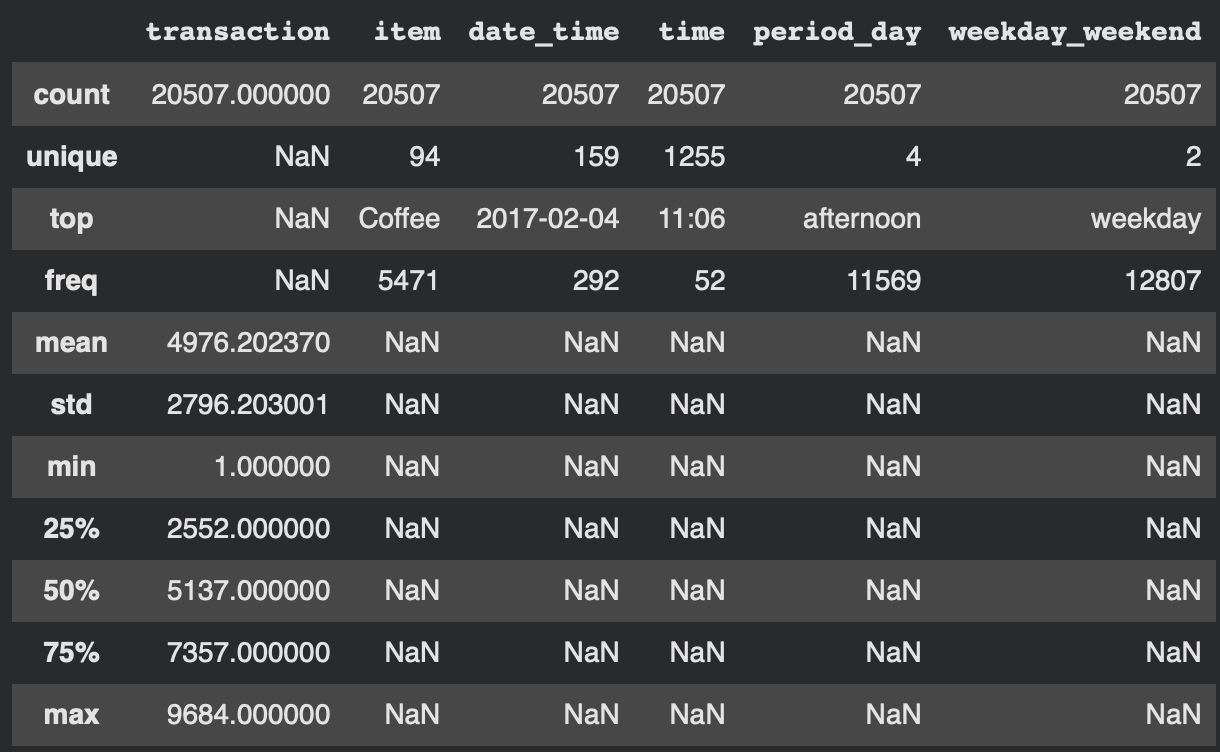

Screenshot above

### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**. Take a screenshot of the figure.

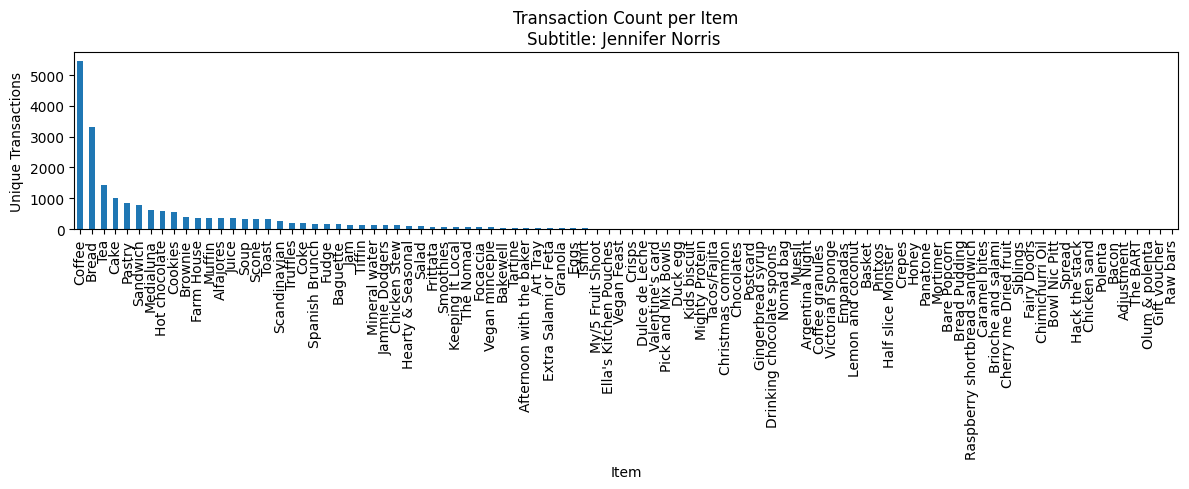

In [18]:
# c) Bar plot of transaction counts per item#
subtitle = "Jennifer Norris "
item_counts = df['item'].value_counts().sort_values(ascending=False) # Calculate and sort counts
ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

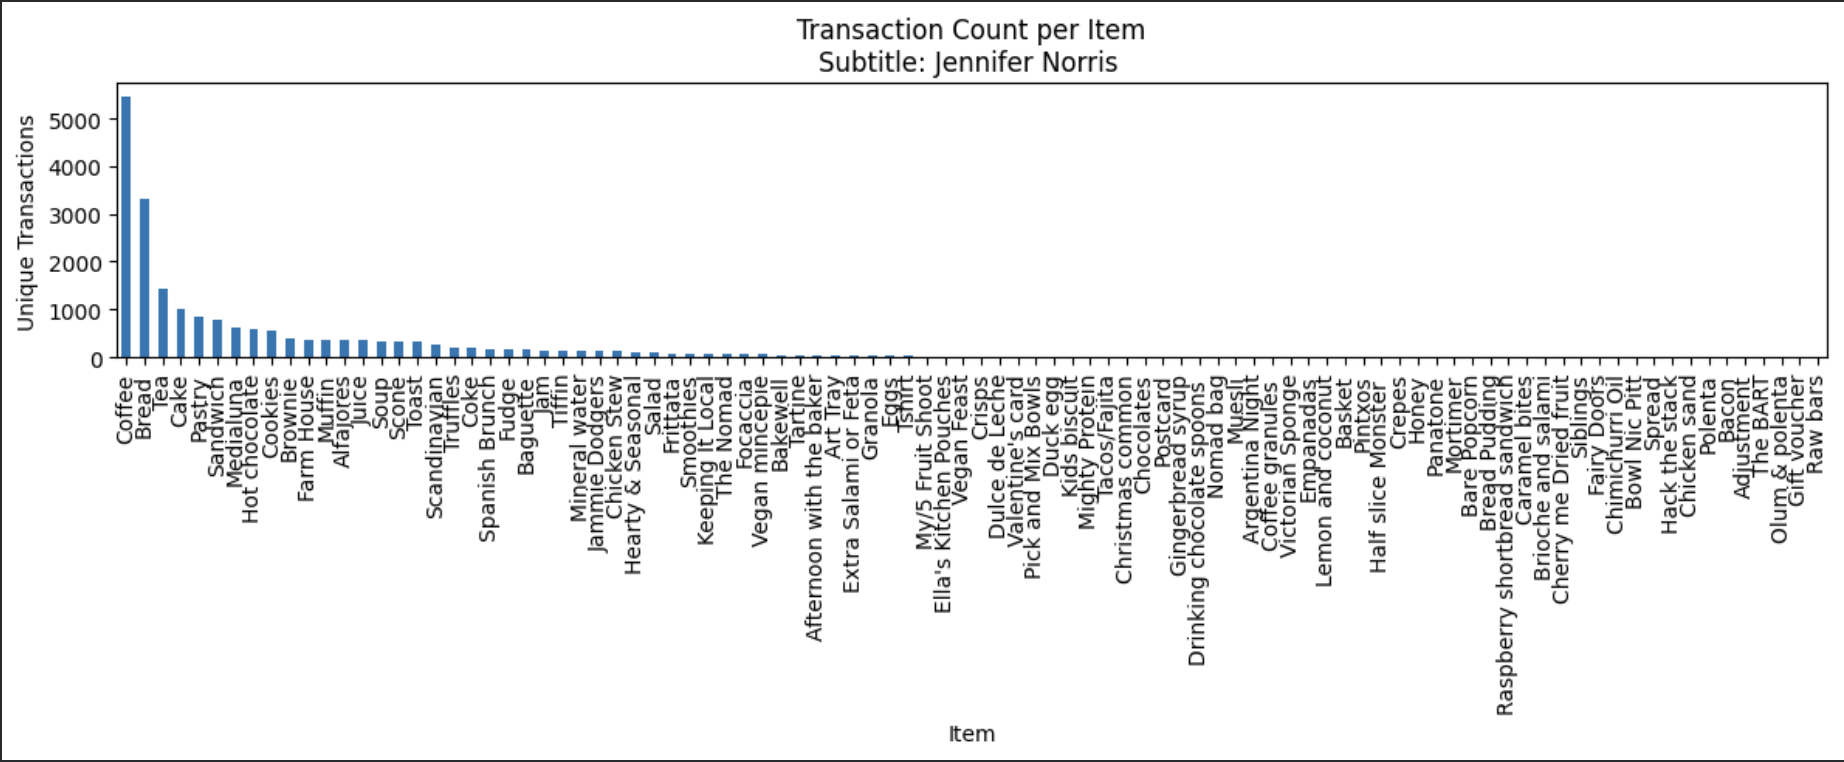

Screenshot of table above

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [12]:
df.columns
items_to_check = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]

for item in items_to_check:
  count = df[df["item"] == item]['transaction'].nunique()
  print(f"{item}: {count}")


Coffee: 4528
Tea: 1350
Alfajores: 344
Juice: 365
Chicken Stew: 123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [55]:
from mlxtend.preprocessing import TransactionEncoder
te=TransactionEncoder ()
te_ary = te. fit(transactions).transform(transactions)
oht = pd. DataFrame(te_ary, columns=te.columns_).astype(bool)
oht. head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [22]:
df['item'] = df['item'].astype(str).str.strip()
transactions = df.groupby('transaction')['item'].apply(lambda x: list(set(x))).tolist()
print(transactions)

[['Bread'], ['Scandinavian'], ['Hot chocolate', 'Jam', 'Cookies'], ['Muffin'], ['Coffee', 'Pastry', 'Bread'], ['Pastry', 'Medialuna', 'Muffin'], ['Pastry', 'Medialuna', 'Tea', 'Coffee'], ['Pastry', 'Bread'], ['Muffin', 'Bread'], ['Scandinavian', 'Medialuna'], ['Medialuna', 'Bread'], ['Pastry', 'Jam', 'Tea', 'Tartine', 'Coffee'], ['Coffee', 'Basket', 'Bread'], ['Pastry', 'Medialuna', 'Bread'], ['Scandinavian', 'Mineral water'], ['Coffee', 'Medialuna', 'Bread'], ['Hot chocolate'], ['Farm House'], ['Farm House', 'Bread'], ['Medialuna', 'Bread'], ['Coffee', 'Medialuna', 'Bread'], ['Jam'], ['Scandinavian', 'Muffin'], ['Bread'], ['Scandinavian'], ['Fudge'], ['Scandinavian'], ['Coffee', 'Bread'], ['Jam', 'Bread'], ['Bread'], ['Basket'], ['Scandinavian', 'Muffin'], ['Coffee'], ['Coffee', 'Muffin'], ['Scandinavian', 'Muffin'], ['Tea', 'Bread'], ['Coffee', 'Bread'], ['Tea', 'Bread'], ['Scandinavian'], ['Juice', 'Coffee', 'Tartine', 'Muffin'], ['Scandinavian'], ['Tea', 'Bread'], ['Scandinavian', 

In [56]:
frequent_itemsets = fpgrowth(oht,
                             min_support=0.02,
                             use_colnames=True)

frequent_itemsets.sort_values(by='support', ascending=False)

,support,itemsets
5,0.478394,(Coffee)
0,0.327205,(Bread)
8,0.142631,(Tea)
12,0.103856,(Cake)
19,0.090016,"(Coffee, Bread)"
6,0.086107,(Pastry)
13,0.071844,(Sandwich)
7,0.061807,(Medialuna)
2,0.058320,(Hot chocolate)
28,0.054728,"(Coffee, Cake)"


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [58]:
from mlxtend.frequent_patterns import association_rules
rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.1)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Coffee),(Bread),0.478394,0.327205,0.090016,0.188163,0.575059,1.0,-0.066517,0.828731,-0.586210,0.125794,-0.206665,0.231634
1,(Bread),(Coffee),0.327205,0.478394,0.090016,0.275105,0.575059,1.0,-0.066517,0.719561,-0.523431,0.125794,-0.389737,0.231634
2,(Hot chocolate),(Coffee),0.058320,0.478394,0.029583,0.507246,1.060311,1.0,0.001683,1.058553,0.060403,0.058333,0.055314,0.284542
3,(Cookies),(Coffee),0.054411,0.478394,0.028209,0.518447,1.083723,1.0,0.002179,1.083174,0.081700,0.055905,0.076787,0.288707
4,(Pastry),(Coffee),0.086107,0.478394,0.047544,0.552147,1.154168,1.0,0.006351,1.164682,0.146161,0.091968,0.141396,0.325764


In [59]:
print(f"Total number of association rules: {len(rules)}")

Total number of association rules: 18


In [60]:
rules = association_rules(frequent_itemsets,metric="confidence",min_threshold=0.1)
print (rules[['antecedents','consequents','support','confidence','lift']])
rules = rules.sort_values(by='lift', ascending=False)

        antecedents consequents   support  confidence      lift
0          (Coffee)     (Bread)  0.090016    0.188163  0.575059
1           (Bread)    (Coffee)  0.090016    0.275105  0.575059
2   (Hot chocolate)    (Coffee)  0.029583    0.507246  1.060311
3         (Cookies)    (Coffee)  0.028209    0.518447  1.083723
4          (Pastry)    (Coffee)  0.047544    0.552147  1.154168
5          (Pastry)     (Bread)  0.029160    0.338650  1.034977
6       (Medialuna)    (Coffee)  0.035182    0.569231  1.189878
7             (Tea)    (Coffee)  0.049868    0.349630  0.730840
8          (Coffee)       (Tea)  0.049868    0.104240  0.730840
9             (Tea)     (Bread)  0.028104    0.197037  0.602181
10          (Juice)    (Coffee)  0.020602    0.534247  1.116750
11         (Coffee)      (Cake)  0.054728    0.114399  1.101515
12           (Cake)    (Coffee)  0.054728    0.526958  1.101515
13            (Tea)      (Cake)  0.023772    0.166667  1.604781
14           (Cake)       (Tea)  0.02377

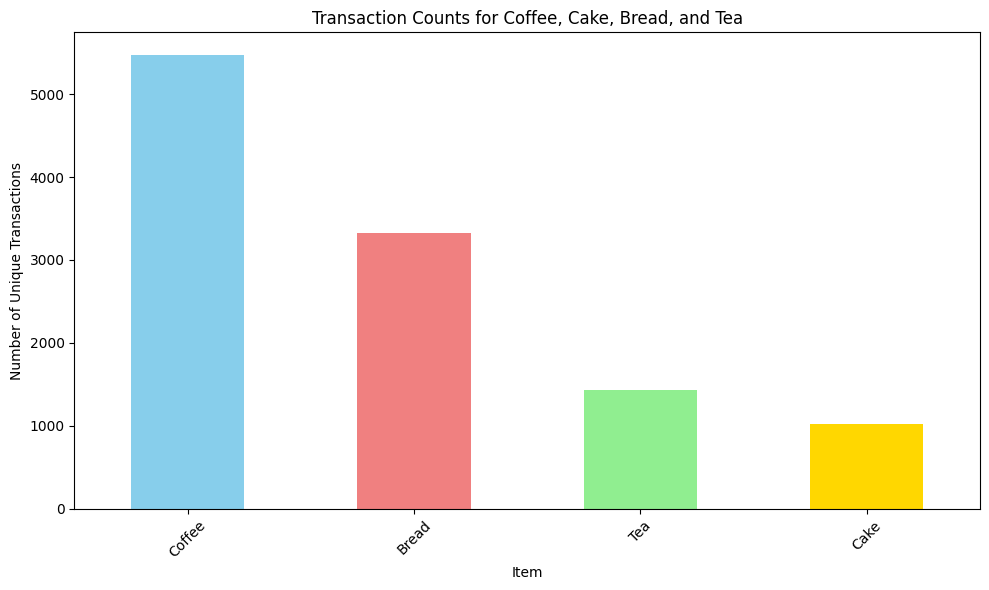

In [63]:
items_of_interest = ["Coffee", "Cake", "Bread", "Tea"]
filtered_df = df[df['item'].isin(items_of_interest)]

specific_item_counts = filtered_df['item'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
specific_item_counts.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen', 'gold'])
plt.title('Transaction Counts for Coffee, Cake, Bread, and Tea')
plt.xlabel('Item')
plt.ylabel('Number of Unique Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:* (The rule stated above is the probability that if a customer buys coffee and cake, how likely are they to buy bread. If it is a frequest itemset, then it means the rule is true and that people are more likely to buy bread if they have already grabbed coffee and cake.

- Support: 1% of all transactions contain Coffee, Cake, and Bread together.
- Confidence: Among shopping baskets that contain Coffee and Cake, 18.34% also include Bread.
- Lift: When lift is greater than 1, it means customers who buy Coffee and Cake are more likely to buy Bread than customers in general.

)

>